In [1]:
# RUSHDA QURESHI-2503951-MSBAWE2

In [4]:
# 1. Setup
import pandas as pd

In [5]:
import numpy as np

In [6]:
import matplotlib.pyplot as plt

In [7]:
import seaborn as sns

In [8]:
from sklearn.model_selection import train_test_split, cross_val_score

In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [10]:
from sklearn.linear_model import LogisticRegression, LinearRegression


In [11]:
from sklearn.metrics import classification_report, mean_squared_error, confusion_matrix

In [12]:
# Adjust display options
pd.set_option('display.max_columns', None)


In [13]:
sns.set_style("whitegrid")

In [14]:
# 2. Data Loading
df = pd.read_csv('data.csv')
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')
print(f"Dataset Shape: {df.shape}")
print(df.info())

Dataset Shape: (569, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  a


Descriptive Statistics:
        radius_mean  texture_mean  perimeter_mean    area_mean  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000        

Text(0.5, 1.0, 'Univariate: Distribution of Radius Mean')

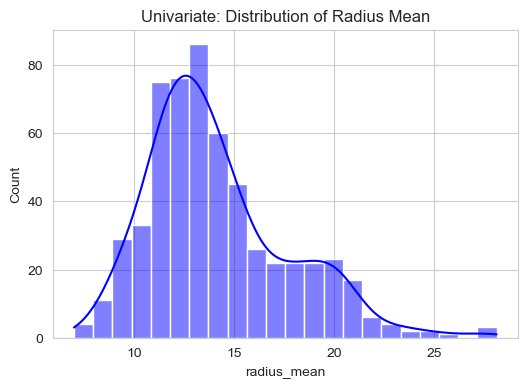

In [15]:
# 3. Exploratory Data Analysis (EDA)
# 4. Univariate analysis
print("\nDescriptive Statistics:\n", df.describe())
plt.figure(figsize=(6, 4))
sns.histplot(df['radius_mean'], kde=True, color='blue')
plt.title('Univariate: Distribution of Radius Mean')

Text(0.5, 1.0, 'Bivariate: Radius vs Texture')

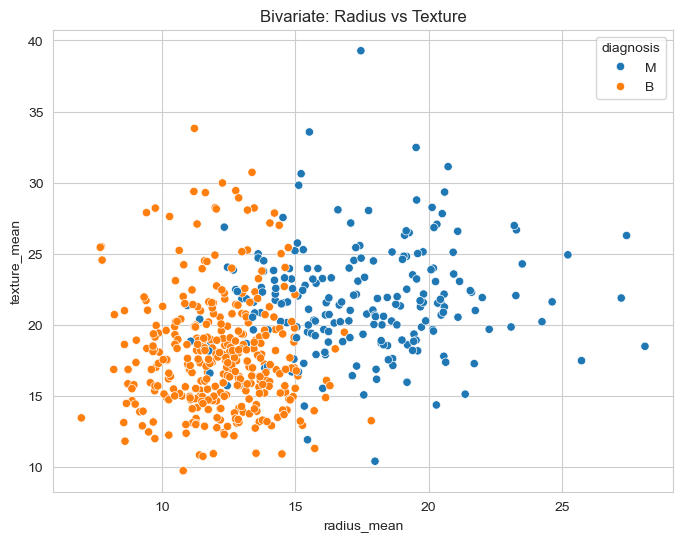

In [16]:
# 5. Bivariate analysis
plt.figure(figsize=(8, 6))
sns.scatterplot(x='radius_mean', y='texture_mean', hue='diagnosis', data=df)
plt.title('Bivariate: Radius vs Texture')

Text(0.5, 1.0, 'Correlation Heatmap')

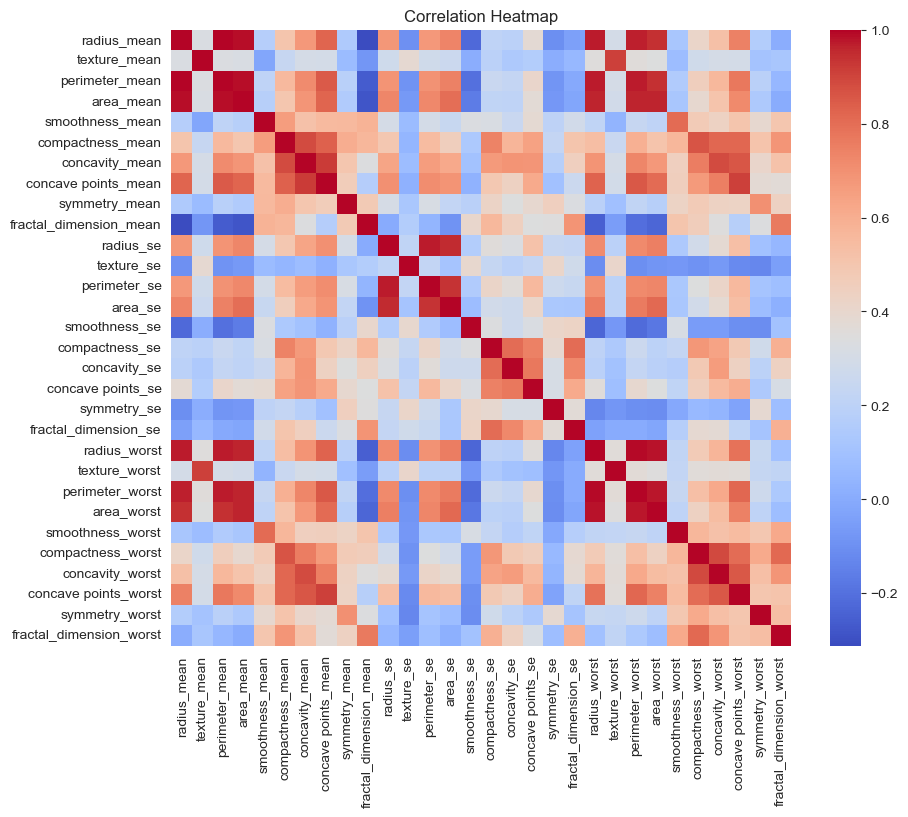

In [17]:
# 6. Correlation matrix and heatmap
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Correlation Heatmap')


Class Proportions:
 diagnosis
B    0.627417
M    0.372583
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Target Class Balance')

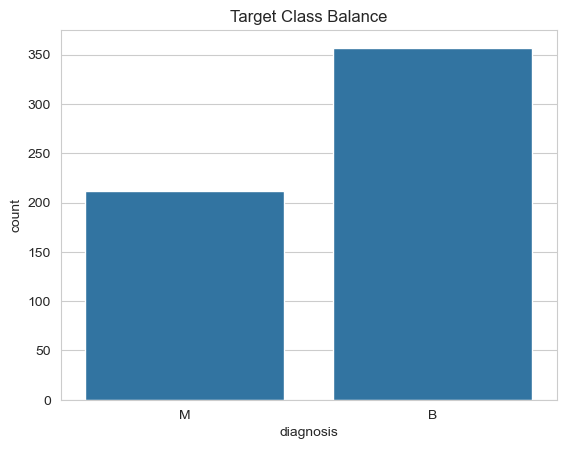

In [18]:
# 7. Class imbalance
print("\nClass Proportions:\n", df['diagnosis'].value_counts(normalize=True))
sns.countplot(x='diagnosis', data=df)
plt.title('Target Class Balance')

In [19]:
# 8. Outlier detection (Z-scores)
# Calculation for radius_mean as an example
z_scores = np.abs((df['radius_mean'] - df['radius_mean'].mean()) / df['radius_mean'].std())
outliers = df[z_scores > 3]
print(f"\nNumber of outliers detected (Radius Mean): {len(outliers)}")


Number of outliers detected (Radius Mean): 5


In [20]:
# 10. Feature Engineering, Encoding and Scaling
# 11. Identify types
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

In [21]:
# 12. Engineer new features (Breast Cancer specific: Interaction)
df['radius_texture_interaction'] = df['radius_mean'] * df['texture_mean']

In [22]:
# 13. Encode categorical variables
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis']) # M=1, B=0

In [23]:
# --- SAVE CLEANED DATASET ---
df.to_csv('processed_breast_cancer.csv', index=False)
print("\nCleaned dataset saved as 'processed_breast_cancer.csv'")


Cleaned dataset saved as 'processed_breast_cancer.csv'


In [24]:
# 15. Train/Test Split and Cross-Validation
# 16. Define X and y
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [25]:
# 17. Split the data (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [26]:
# 14. Scale numerical variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
# 19. Linear and Logistic Regression Models
# 20. Linear Regression (Baseline)
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)
print(f"\nLinear Regression R-squared: {lin_reg.score(X_test_scaled, y_test):.4f}")


Linear Regression R-squared: 0.7310


In [29]:
# 21. Logistic Regression (Primary Model)
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [30]:
# Cross-validation
cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f"Logistic Regression CV Accuracy: {cv_scores.mean():.4f}")

Logistic Regression CV Accuracy: 0.9714


Text(0.5, 1.0, 'Logistic Regression Confusion Matrix')

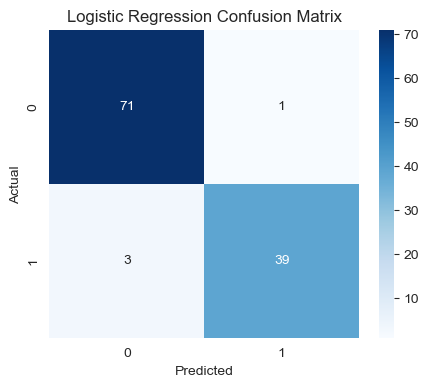

In [31]:
# Confusion Matrix Heatmap
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, log_reg.predict(X_test_scaled))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')

In [32]:
# 22. Interpretation
# Check feature influence via coefficients
importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': log_reg.coef_[0]})
importance = importance.sort_values(by='Coefficient', ascending=False)
print("\nTop 5 Influential Features:\n", importance.head(5))


Top 5 Influential Features:
                 Feature  Coefficient
21        texture_worst     1.358730
10            radius_se     1.232630
28       symmetry_worst     1.070513
7   concave points_mean     0.945082
26      concavity_worst     0.921778
